![](./Images/image.png)

# Mosaic AI Agent Framework + Lakebase

### Install dependencies

In [0]:
%pip install -U -qqqq databricks-langchain langgraph==0.5.3 uv databricks-agents mlflow-skinny[databricks] \
  langgraph-checkpoint-postgres==2.0.21 psycopg[binary,pool] bs4
dbutils.library.restartPython()

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


## First time setup only: Set up checkpointer with your Lakebase instance

In [0]:
import os
import uuid
from databricks.sdk import WorkspaceClient
from psycopg_pool import ConnectionPool
import psycopg
from langgraph.checkpoint.postgres import PostgresSaver

# TODO: Fill in your lakebase instance details here. For the username, create a
# Service Principal and grant it databricks_superuser permissions onto the lakebase instance.
# See Service Principal Documentation for more information:
# https://docs.databricks.com/en/admin/users-groups/service-principals
# Use the Service Principal client id and secret as the SP_CLIENT_ID/SP_CLIENT_SECRET
# This will help initialize the checkpointers
DB_INSTANCE_NAME = "lakebasebaraldi"  
DB_NAME          = "databricks_postgres"
SP_CLIENT_ID      = "id"
SP_CLIENT_SECRET      = "password"
SSL_MODE         = "require"
DB_HOST = "instance-e757058d-4c1e-4257-b271-d092648bea3f.database.azuredatabricks.net"
DB_PORT = 5432
WORKSPACE_HOST = "https://adb-864.15.azuredatabricks.net/"

w = WorkspaceClient(
  host = WORKSPACE_HOST,
  client_id = SP_CLIENT_ID,
  client_secret = SP_CLIENT_SECRET
)

def db_password_provider() -> str:
    """
    Ask Databricks to mint a fresh DB credential for this instance.
    """
    cred = w.database.generate_database_credential(
        request_id=str(uuid.uuid4()),
        instance_names=[DB_INSTANCE_NAME],
    )
    return cred.token

class CustomConnection(psycopg.Connection):
    """
    A psycopg Connection subclass that injects a fresh password
    *at connection time* (only when the pool creates a new connection).
    """
    @classmethod
    def connect(cls, conninfo="", **kwargs):
        # Append the new password to kwargs
        kwargs["password"] = db_password_provider()
        # Call the superclass's connect method with updated kwargs
        return super().connect(conninfo, **kwargs)

pool = ConnectionPool(
    conninfo=f"dbname={DB_NAME} user={SP_CLIENT_ID} host={DB_HOST} port={DB_PORT} sslmode={SSL_MODE}",
    connection_class=CustomConnection,
    min_size=1,
    max_size=10,
    open=True,
)

# Use the pool to initialize your checkpoint tables
with pool.connection() as conn:
    conn.autocommit = True   # disable transaction wrapping
    checkpointer = PostgresSaver(conn)
    checkpointer.setup()
    conn.autocommit = False  # restore default if you want transactions later

    with conn.cursor() as cur:
        cur.execute("select 1")
    print("✅ Pool connected and checkpoint tables are ready.")

✅ Pool connected and checkpoint tables are ready.


# Define the agent in code

## Write agent code to file agent.py
Define the agent code in a single cell below. This lets you write the agent code to a local Python file, using the `%%writefile` magic command, for subsequent logging and deployment.

## Wrap the LangGraph agent using the ResponsesAgent interface
For compatibility with Databricks AI features, the `LangGraphResponsesAgent` class implements the `ResponsesAgent` interface to wrap the LangGraph agent.

Databricks recommends using `ResponsesAgent` as it simplifies authoring multi-turn conversational agents using an open source standard. See MLflow's [ResponsesAgent documentation](https://www.mlflow.org/docs/latest/llms/responses-agent-intro/).

In [0]:
%%writefile agentlakebase.py
import json
import logging
import os
import time
import urllib.parse
import uuid
from threading import Lock
from typing import Annotated, Any, Generator, Optional, Sequence, TypedDict

import mlflow
from databricks_langchain import (
    ChatDatabricks,
    DatabricksFunctionClient,
    UCFunctionToolkit,
)
from databricks.sdk import WorkspaceClient
from langchain_core.messages import (
    AIMessage,
    AIMessageChunk,
    BaseMessage,
    ToolMessage
)
from langchain_core.runnables import RunnableConfig, RunnableLambda
from langgraph.checkpoint.postgres import PostgresSaver
from langgraph.graph import END, StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt.tool_node import ToolNode
from mlflow.pyfunc import ResponsesAgent
from mlflow.types.responses import (
    ResponsesAgentRequest,
    ResponsesAgentResponse,
    ResponsesAgentStreamEvent,
)
import psycopg
from psycopg_pool import ConnectionPool
from psycopg.rows import dict_row
from contextlib import contextmanager

logger = logging.getLogger(__name__)
logging.basicConfig(level=os.getenv("LOG_LEVEL", "INFO"))


############################################
# Define your LLM endpoint and system prompt
############################################
# TODO: Replace with your model serving endpoint
LLM_ENDPOINT_NAME = "databricks-claude-3-7-sonnet"

# TODO: Update with your system prompt
SYSTEM_PROMPT = "You are a helpful assistant. Use the available tools to answer questions."

# TODO: Fill in Lakebase config values here
LAKEBASE_CONFIG = {
    "instance_name": "lakebasebaraldi",
    "conn_host": "instance-e757058d-4c1e-4257-b271-d092648bea3f.database.azuredatabricks.net",
    "conn_db_name": "databricks_postgres",
    "conn_ssl_mode": "require",
}

###############################################################################
## Define tools for your agent,enabling it to retrieve data or take actions
## beyond text generation
## To create and see usage examples of more tools, see
## https://docs.databricks.com/en/generative-ai/agent-framework/agent-tool.html
###############################################################################

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]
    custom_inputs: Optional[dict[str, Any]]
    custom_outputs: Optional[dict[str, Any]]


def normalize_location_with_llm(state: AgentState) -> str:

    llm=ChatDatabricks(endpoint=LLM_ENDPOINT_NAME)
    
    prompt = (
        "Extraia da seguinte frase somente a cidade e o país no formato 'Cidade,PAÍS' (com a sigla do país em maiúsculas), prontos para busca na OpenWeatherMap: "
        f"{state}\n"
        "Responda apenas com a string formatada."
    )
    resposta = llm.invoke(prompt)
    if hasattr(resposta, "content") and not isinstance(resposta, str):
        return resposta.content.strip()
    state["messages"].append(AIMessage(content=str(text)))
    state["last_result"] = text
    return text


# Ferramenta: info Databricks
def get_info(state: AgentState):
    """Busca informação no Wikipedia sobre a Databricks."""
    import requests
    from bs4 import BeautifulSoup
    url = "https://en.wikipedia.org/wiki/Databricks"
    headers = {'User-Agent': 'Mozilla/5.0'}
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.text, "html.parser")
    text = soup.get_text(separator='\n', strip=True)
    state["messages"].append(AIMessage(content=str(text)))
    state["last_result"] = text
    return state

# Ferramenta: Clima
def get_weather(state: AgentState):
    """Busca informações sobre clima."""
    import requests
    location = normalize_location_with_llm(state)
    api_key = 'api_key'
    response = requests.get(
        "https://api.openweathermap.org/data/2.5/weather",
        params={"q": location, "appid": api_key, "units": "metric", "lang": "pt"}
    )
    data = response.json()
    #if "main" in data:
    result = data
    #else:
    #result = "Não foi possível encontrar a temperatura desse local."
    state["messages"].append(AIMessage(content=str(result)))
    state["last_result"] = result
    return state

tools = [get_info,get_weather]

# Example UC tools; add your own as needed
UC_TOOL_NAMES: list[str] = []
if UC_TOOL_NAMES:
    uc_toolkit = UCFunctionToolkit(function_names=UC_TOOL_NAMES)
    tools.extend(uc_toolkit.tools)

# Use Databricks vector search indexes as tools
# See https://docs.databricks.com/en/generative-ai/agent-framework/unstructured-retrieval-tools.html#locally-develop-vector-search-retriever-tools-with-ai-bridge
# List to store vector search tool instances for unstructured retrieval.
VECTOR_SEARCH_TOOLS = []

# To add vector search retriever tools,
# use VectorSearchRetrieverTool and create_tool_info,
# then append the result to TOOL_INFOS.
# Example:
# VECTOR_SEARCH_TOOLS.append(
#     VectorSearchRetrieverTool(
#         index_name="",
#         # filters="..."
#     )
# )

tools.extend(VECTOR_SEARCH_TOOLS)

#####################
## Define agent logic
#####################





class CredentialConnection(psycopg.Connection):
    """Custom connection class that generates fresh OAuth tokens with caching."""
    
    workspace_client = None
    instance_name = None
    
    # Cache attributes
    _cached_credential = None
    _cache_timestamp = None
    _cache_duration = 3000  # 50 minutes in seconds (50 * 60)
    _cache_lock = Lock()
    
    @classmethod
    def connect(cls, conninfo='', **kwargs):
        """Override connect to inject OAuth token with 50-minute caching"""
        if cls.workspace_client is None or cls.instance_name is None:
            raise ValueError("workspace_client and instance_name must be set on CredentialConnection class")
        
        # Get cached or fresh credential and append the new password to kwargs
        credential_token = cls._get_cached_credential()
        kwargs['password'] = credential_token
        
        # Call the superclass's connect method with updated kwargs
        return super().connect(conninfo, **kwargs)
    
    @classmethod
    def _get_cached_credential(cls):
        """Get credential from cache or generate a new one if cache is expired"""
        with cls._cache_lock:
            current_time = time.time()
            
            # Check if we have a valid cached credential
            if (cls._cached_credential is not None and 
                cls._cache_timestamp is not None and 
                current_time - cls._cache_timestamp < cls._cache_duration):
                return cls._cached_credential
            
            # Generate new credential
            credential = cls.workspace_client.database.generate_database_credential(
                request_id=str(uuid.uuid4()),
                instance_names=[cls.instance_name]
            )
            
            # Cache the new credential
            cls._cached_credential = credential.token
            cls._cache_timestamp = current_time
            
            return cls._cached_credential


class LangGraphResponsesAgent(ResponsesAgent):
    """Stateful agent using ResponsesAgent with Lakebase PostgreSQL checkpointing.
    
    Features:
    - Connection pooling with credential rotation and caching
    - Thread-based conversation state persistence
    - Tool support with UC functions
    """

    def __init__(self, lakebase_config: dict[str, Any]):
        self.lakebase_config = lakebase_config
        self.workspace_client = WorkspaceClient()
        
        # Model and tools
        self.model = ChatDatabricks(endpoint=LLM_ENDPOINT_NAME)
        self.system_prompt = SYSTEM_PROMPT
        self.model_with_tools = self.model.bind_tools(tools) if tools else self.model
        
        # Connection pool configuration
        self.pool_min_size = int(os.getenv("DB_POOL_MIN_SIZE", "1"))
        self.pool_max_size = int(os.getenv("DB_POOL_MAX_SIZE", "10"))
        self.pool_timeout = float(os.getenv("DB_POOL_TIMEOUT", "30.0"))
        
        # Token cache duration (in minutes, can be overridden via env var)
        cache_duration_minutes = int(os.getenv("DB_TOKEN_CACHE_MINUTES", "50"))
        CredentialConnection._cache_duration = cache_duration_minutes * 60
        
        # Initialize the connection pool with rotating credentials
        self._connection_pool = self._create_rotating_pool()
        
        mlflow.langchain.autolog()

    def _get_username(self) -> str:
        """Get the username for database connection"""
        try:
            sp = self.workspace_client.current_service_principal.me()
            return sp.application_id
        except Exception:
            user = self.workspace_client.current_user.me()
            return user.user_name

    def _create_rotating_pool(self) -> ConnectionPool:
        """Create a connection pool that automatically rotates credentials with caching"""
        # Set the workspace client and instance name on the custom connection class
        CredentialConnection.workspace_client = self.workspace_client
        CredentialConnection.instance_name = self.lakebase_config["instance_name"]
        
        username = self._get_username()
        host = self.lakebase_config["conn_host"]
        database = self.lakebase_config.get("conn_db_name", "databricks_postgres")
        
        # Create pool with custom connection class
        pool = ConnectionPool(
            conninfo=f"dbname={database} user={username} host={host} sslmode=require",
            connection_class=CredentialConnection,
            min_size=self.pool_min_size,
            max_size=self.pool_max_size,
            timeout=self.pool_timeout,
            open=True,
            kwargs={
                "autocommit": True, # Required for the .setup() method to properly commit the checkpoint tables to the database
                "row_factory": dict_row, # Required because the PostgresSaver implementation accesses database rows using dictionary-style syntax
                "keepalives": 1,
                "keepalives_idle": 30,
                "keepalives_interval": 10,
                "keepalives_count": 5,
            }
        )
        
        # Test the pool
        try:
            with pool.connection() as conn:
                with conn.cursor() as cursor:
                    cursor.execute("SELECT 1")
            logger.info(
                f"Connection pool with rotating credentials created successfully "
                f"(min={self.pool_min_size}, max={self.pool_max_size}, "
                f"token_cache={CredentialConnection._cache_duration / 60:.0f} minutes)"
            )
        except Exception as e:
            pool.close()
            raise ConnectionError(f"Failed to create connection pool: {e}")
        
        return pool
    
    @contextmanager
    def get_connection(self):
        """Context manager to get a connection from the pool"""
        with self._connection_pool.connection() as conn:
            yield conn
    
    def _langchain_to_responses(self, messages: list[BaseMessage]) -> list[dict[str, Any]]:
        """Convert from LangChain messages to Responses API format"""
        responses = []
        for message in messages:
            message_dict = message.model_dump()
            print(message_dict)
            msg_type = message_dict["type"]
            
            if msg_type == "ai":
                if tool_calls := message_dict.get("tool_calls"):
                    for tool_call in tool_calls:
                        responses.append(
                            self.create_function_call_item(
                                id=message_dict.get("id") or str(uuid.uuid4()),
                                call_id=tool_call["id"],
                                name=tool_call["name"],
                                arguments=json.dumps(tool_call["args"]),
                            )
                        )
                else:
                    responses.append(
                        self.create_text_output_item(
                            text=message_dict.get("content", ""),
                            id=message_dict.get("id") or str(uuid.uuid4()),
                        )
                    )
            elif msg_type == "tool":
                responses.append(
                    self.create_function_call_output_item(
                        call_id=message_dict["tool_call_id"],
                        output=message_dict["content"],
                    )
                )
            elif msg_type == "human":
                responses.append({
                    "role": "user",
                    "content": message_dict.get("content", "")
                })
        
        return responses
    
    def _create_graph(self, checkpointer: PostgresSaver):
        """Create the LangGraph workflow"""
        def should_continue(state: AgentState):
            messages = state["messages"]
            last_message = messages[-1]
            if isinstance(last_message, AIMessage) and last_message.tool_calls:
                return "continue"
            return "end"
        
        if self.system_prompt:
            preprocessor = RunnableLambda(
                lambda state: [{"role": "system", "content": self.system_prompt}] + state["messages"]
            )
        else:
            preprocessor = RunnableLambda(lambda state: state["messages"])
        
        model_runnable = preprocessor | self.model_with_tools
        
        def call_model(state: AgentState, config: RunnableConfig):
            response = model_runnable.invoke(state, config)
            return {"messages": [response]}
        
        workflow = StateGraph(AgentState)
        workflow.add_node("agent", RunnableLambda(call_model))
        print("TOOLS:")
        print(tools)
        
        if tools:
            workflow.add_node("tools", ToolNode(tools))
            workflow.add_conditional_edges(
                "agent",
                should_continue,
                {"continue": "tools", "end": END}
            )
            workflow.add_edge("tools", "agent")
        else:
            workflow.add_edge("agent", END)
        
        workflow.set_entry_point("agent")
        
        return workflow.compile(checkpointer=checkpointer)
    
    def predict(self, request: ResponsesAgentRequest) -> ResponsesAgentResponse:
        """Non-streaming prediction"""
        # The same thread_id is used by BOTH predict() and predict_stream()
        ci = dict(request.custom_inputs or {})
        if "thread_id" not in ci:
            ci["thread_id"] = str(uuid.uuid4())
        request.custom_inputs = ci
        #print(request)

        outputs = [
            event.item
            for event in self.predict_stream(request)
            if event.type == "response.output_item.done"
        ]
        return ResponsesAgentResponse(output=outputs, custom_outputs={"thread_id": ci["thread_id"]})
    
    def predict_stream(
        self,
        request: ResponsesAgentRequest,
    ) -> Generator[ResponsesAgentStreamEvent, None, None]:
        """Streaming prediction with PostgreSQL checkpointing"""
        # Get thread ID from custom inputs or generate new one
        thread_id = (request.custom_inputs or {}).get("thread_id", str(uuid.uuid4()))
        
        # Convert incoming Responses messages to ChatCompletions format
        # LangChain will automatically convert from ChatCompletions to LangChain format
        cc_msgs = self.prep_msgs_for_cc_llm([i.model_dump() for i in request.input])
        langchain_msgs = cc_msgs
        
        checkpoint_config = {"configurable": {"thread_id": thread_id}}
        
        # Use connection from pool
        with self.get_connection() as conn:            
            # Create checkpointer and graph
            checkpointer = PostgresSaver(conn)
            graph = self._create_graph(checkpointer)
            
            # Stream the graph execution
            for event in graph.stream(
                {"messages": langchain_msgs},
                checkpoint_config,
                stream_mode=["updates", "messages"]
            ):
                if event[0] == "updates":
                    for node_data in event[1].values():
                        for item in self._langchain_to_responses(node_data["messages"]):
                            yield ResponsesAgentStreamEvent(
                                type="response.output_item.done",
                                item=item
                            )
                # Stream message chunks for real-time text generation
                elif event[0] == "messages":
                    try:
                        chunk = event[1][0]
                        if isinstance(chunk, AIMessageChunk) and chunk.content:
                            yield ResponsesAgentStreamEvent(
                                **self.create_text_delta(
                                    delta=chunk.content,
                                    item_id=chunk.id
                                ),
                            )
                    except Exception as e:
                        logger.error(f"Error streaming chunk: {e}")


# ----- Export model -----
AGENT = LangGraphResponsesAgent(LAKEBASE_CONFIG)
mlflow.models.set_model(AGENT)

Writing agentlakebase.py


In [0]:
# Reiniciar sys
dbutils.library.restartPython()

# Test the Agent locally

INFO:agentlakebase:Connection pool with rotating credentials created successfully (min=1, max=10, token_cache=50 minutes)


TOOLS:
[<function get_info at 0x7f3c0452f920>, <function get_weather at 0x7f3c03dc4ae0>]


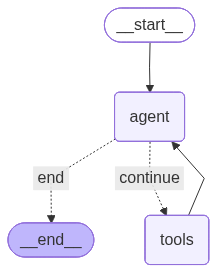

In [0]:
from agentlakebase import LangGraphResponsesAgent

agent = LangGraphResponsesAgent(LAKEBASE_CONFIG)

# Exibir o draw_mermaid
from IPython.display import Image, display

display(Image(agent._create_graph(checkpointer=None).get_graph().draw_mermaid_png()))

In [0]:
from agentlakebase import AGENT
# Message 1, don't include thread_id (creates new thread)
result = AGENT.predict({
    "input": [{"role": "user", "content": "oi, tudo bem?"}]
})
print(result.model_dump(exclude_none=True))
thread_id = result.custom_outputs["thread_id"]

TOOLS:
[<function get_info at 0x7f3c0452f920>, <function get_weather at 0x7f3c03dc4ae0>]


INFO:httpx:HTTP Request: POST https://adb-864885279849395.15.azuredatabricks.net/serving-endpoints/chat/completions "HTTP/1.1 200 OK"


{'content': 'Olá! Tudo bem, e com você? Como posso ajudar você hoje? Estou à disposição para responder suas perguntas ou fornecer informações usando as ferramentas disponíveis. Posso buscar informações sobre a Databricks ou sobre o clima. O que você gostaria de saber?', 'additional_kwargs': {}, 'response_metadata': {'finish_reason': 'stop'}, 'type': 'ai', 'name': None, 'id': 'run--e0ab0415-84c3-4084-8e70-8e8d28d58b82', 'example': False, 'tool_calls': [], 'invalid_tool_calls': [], 'usage_metadata': {'input_tokens': 2166, 'output_tokens': 160, 'total_tokens': 2326}}
{'object': 'response', 'output': [{'type': 'message', 'id': 'run--e0ab0415-84c3-4084-8e70-8e8d28d58b82', 'content': [{'text': 'Olá! Tudo bem, e com você? Como posso ajudar você hoje? Estou à disposição para responder suas perguntas ou fornecer informações usando as ferramentas disponíveis. Posso buscar informações sobre a Databricks ou sobre o clima. O que você gostaria de saber?', 'type': 'output_text'}], 'role': 'assistant'

Trace(trace_id=tr-88496b80868b7c3e8a45e834902d767b)

In [0]:
# Message 2, include thread ID and notice how agent remembers context from previous predict message
response2 = AGENT.predict({
    "input": [{"role": "user", "content": "qual foi a primeira coisa que eu te disse?"}],
    "custom_inputs": {"thread_id": thread_id}
})
print("Response 2:", response2.model_dump(exclude_none=True))

TOOLS:
[<function get_info at 0x7f3c0452f920>, <function get_weather at 0x7f3c03dc4ae0>]


INFO:httpx:HTTP Request: POST https://adb-864885279849395.15.azuredatabricks.net/serving-endpoints/chat/completions "HTTP/1.1 200 OK"


{'content': 'A primeira coisa que você me disse foi "oi, tudo bem?". Foi uma saudação simples para iniciar nossa conversa.', 'additional_kwargs': {}, 'response_metadata': {'finish_reason': 'stop'}, 'type': 'ai', 'name': None, 'id': 'run--571cff4f-f59a-4897-85a3-10e6e1596a4e', 'example': False, 'tool_calls': [], 'invalid_tool_calls': [], 'usage_metadata': {'input_tokens': 2354, 'output_tokens': 70, 'total_tokens': 2424}}
Response 2: {'object': 'response', 'output': [{'type': 'message', 'id': 'run--571cff4f-f59a-4897-85a3-10e6e1596a4e', 'content': [{'text': 'A primeira coisa que você me disse foi "oi, tudo bem?". Foi uma saudação simples para iniciar nossa conversa.', 'type': 'output_text'}], 'role': 'assistant'}], 'custom_outputs': {'thread_id': 'd2166db4-08a1-4c07-9306-3e567cd14e22'}}


Trace(trace_id=tr-c29144c4ff8151eb0008e6683f32d9f1)

In [0]:
# predict stream example
for chunk in AGENT.predict_stream({
    "input": [{"role": "user", "content": "O que eu te disse antes?"}],
    "custom_inputs": {"thread_id": thread_id}
}):
    print("Chunk:", chunk.model_dump(exclude_none=True))

TOOLS:
[<function get_info at 0x7f3c0452f920>, <function get_weather at 0x7f3c03dc4ae0>]


INFO:httpx:HTTP Request: POST https://adb-864885279849395.15.azuredatabricks.net/serving-endpoints/chat/completions "HTTP/1.1 200 OK"


Chunk: {'type': 'response.output_text.delta', 'item_id': 'run--8cd27e88-77f4-413c-81f5-6a4fd8d4dfee', 'delta': 'A'}
Chunk: {'type': 'response.output_text.delta', 'item_id': 'run--8cd27e88-77f4-413c-81f5-6a4fd8d4dfee', 'delta': ' única coisa que você'}
Chunk: {'type': 'response.output_text.delta', 'item_id': 'run--8cd27e88-77f4-413c-81f5-6a4fd8d4dfee', 'delta': ' me disse até agora foi'}
Chunk: {'type': 'response.output_text.delta', 'item_id': 'run--8cd27e88-77f4-413c-81f5-6a4fd8d4dfee', 'delta': ' "oi,'}
Chunk: {'type': 'response.output_text.delta', 'item_id': 'run--8cd27e88-77f4-413c-81f5-6a4fd8d4dfee', 'delta': ' tudo bem?'}
Chunk: {'type': 'response.output_text.delta', 'item_id': 'run--8cd27e88-77f4-413c-81f5-6a4fd8d4dfee', 'delta': '", que foi sua'}
Chunk: {'type': 'response.output_text.delta', 'item_id': 'run--8cd27e88-77f4-413c-81f5-6a4fd8d4dfee', 'delta': ' primeira mens'}
Chunk: {'type': 'response.output_text.delta', 'item_id': 'run--8cd27e88-77f4-413c-81f5-6a4fd8d4dfee', 'delt

Trace(trace_id=tr-74a7aa9c660133a202a6c261c58bfcce)

# Log the agent as an MLflow model


In [0]:
# Determine Databricks resources to specify for automatic auth passthrough at deployment time
import mlflow
from agentlakebase import tools, LLM_ENDPOINT_NAME, LAKEBASE_CONFIG
from databricks_langchain import VectorSearchRetrieverTool
from mlflow.models.resources import DatabricksFunction, DatabricksServingEndpoint, DatabricksLakebase
from unitycatalog.ai.langchain.toolkit import UnityCatalogTool
from pkg_resources import get_distribution

resources = [DatabricksServingEndpoint(LLM_ENDPOINT_NAME), DatabricksLakebase(database_instance_name=LAKEBASE_CONFIG["instance_name"])]

for tool in tools:
    if isinstance(tool, VectorSearchRetrieverTool):
        resources.extend(tool.resources)
    elif isinstance(tool, UnityCatalogTool):
        resources.append(DatabricksFunction(function_name=tool.uc_function_name))

input_example = {
    "input": [
        {
            "role": "user",
            "content": "What is an LLM agent?"
        }
    ],
    "custom_inputs": {"thread_id": "example-thread-123"},
}

with mlflow.start_run():
    logged_agent_info = mlflow.pyfunc.log_model(
        name="agentlakebase",
        python_model="agentlakebase.py",
        input_example=input_example,
        resources=resources,
        pip_requirements=[
            "databricks-langchain",
            f"databricks-connect=={get_distribution('databricks-connect').version}",
            f"langgraph=={get_distribution('langgraph').version}",
            f"langgraph-checkpoint-postgres=={get_distribution('langgraph-checkpoint-postgres').version}",
            f"psycopg[binary,pool]",
            f"pydantic=={get_distribution('pydantic').version}",
            "bs4"
        ]
    )

🔗 View Logged Model at: https://adb-864885279849395.15.azuredatabricks.net/ml/experiments/9643281737244096aa61c2e3ecb971a7/models/m-5bdbab3ae343487e8451a83ff23dd9fe?o=864885279849395
INFO:code_model_60a0c8f9d89042989a4555dd4dfb4bc1:Connection pool with rotating credentials created successfully (min=1, max=10, token_cache=50 minutes)
2025/10/28 15:01:08 INFO mlflow.pyfunc: Predicting on input example to validate output


TOOLS:
[<function get_info at 0x7f3bf7318c20>, <function get_weather at 0x7f3bf7318cc0>]


INFO:httpx:HTTP Request: POST https://adb-864885279849395.15.azuredatabricks.net/serving-endpoints/chat/completions "HTTP/1.1 200 OK"


{'content': "I'd be happy to provide information about LLM agents. Let me search for information about this topic.", 'additional_kwargs': {'tool_calls': [{'index': 0, 'id': 'toolu_bdrk_01B7UFq8KdHMFqpYTXvH3m2C', 'function': {'arguments': '{"state": {"messages":[{"content":"What is an LLM agent?","type":"human"}],"custom_inputs":null,"custom_outputs":null}}', 'name': 'get_info'}, 'type': 'function'}]}, 'response_metadata': {'finish_reason': 'tool_calls'}, 'type': 'ai', 'name': None, 'id': 'run--46dd38fa-054c-4d7b-8880-5fbb8d7dbf1c', 'example': False, 'tool_calls': [{'name': 'get_info', 'args': {'state': {'messages': [{'content': 'What is an LLM agent?', 'type': 'human'}], 'custom_inputs': None, 'custom_outputs': None}}, 'id': 'toolu_bdrk_01B7UFq8KdHMFqpYTXvH3m2C', 'type': 'tool_call'}], 'invalid_tool_calls': [], 'usage_metadata': {'input_tokens': 2168, 'output_tokens': 224, 'total_tokens': 2392}}
{'content': '{\'messages\': [BaseMessage(content=\'What is an LLM agent?\', additional_kwar

INFO:httpx:HTTP Request: POST https://adb-864885279849395.15.azuredatabricks.net/serving-endpoints/chat/completions "HTTP/1.1 200 OK"


...

{'content': "I see that the search function is only returning information about Databricks rather than LLM agents. Let me provide you with information about LLM agents based on my knowledge.\n\n# What is an LLM Agent?\n\nAn LLM (Large Language Model) agent is an AI system that combines a large language model with additional capabilities that allow it to interact with its environment, make decisions, and take actions to accomplish specific tasks. Unlike a standard LLM that simply generates text responses, an LLM agent can:\n\n## Key Components of LLM Agents\n\n1. **Large Language Model Core**: The foundation of an agent is a large language model (like GPT-4, Claude, Llama, etc.) that provides reasoning, language understanding, and generation capabilities.\n\n2. **Tool Use**: Agents can access and use various tools and APIs to interact with external systems, such as:\n   - Web search engines\n   - Databases\n   - Code interpreters\n   - File systems\n   - Other software applications\n\n3

INFO:code_model_39c8b8612fb9433e9be5911728666efb:Connection pool with rotating credentials created successfully (min=1, max=10, token_cache=50 minutes)


TOOLS:
[<function get_info at 0x7f3bf6e92520>, <function get_weather at 0x7f3bf6e93f60>]


INFO:httpx:HTTP Request: POST https://adb-864885279849395.15.azuredatabricks.net/serving-endpoints/chat/completions "HTTP/1.1 200 OK"


{'content': "# What is an LLM Agent?\n\nAn LLM (Large Language Model) agent is an AI system that combines a large language model with additional capabilities that allow it to interact with its environment, make decisions, and take actions to accomplish specific tasks. Unlike a standard LLM that simply generates text responses, an LLM agent can:\n\n## Key Components of LLM Agents\n\n1. **Large Language Model Core**: The foundation of an agent is a large language model (like GPT-4, Claude, Llama, etc.) that provides reasoning, language understanding, and generation capabilities.\n\n2. **Tool Use**: Agents can access and use various tools and APIs to interact with external systems, such as:\n   - Web search engines\n   - Databases\n   - Code interpreters\n   - File systems\n   - Other software applications\n\n3. **Memory Systems**: Agents often have memory mechanisms to maintain context over long interactions and remember previous actions and their outcomes.\n\n4. **Planning and Reasoning

# Evaluate the agent with Agent Evaluation


In [0]:
import mlflow
from mlflow.genai.scorers import RelevanceToQuery, RetrievalGroundedness, RetrievalRelevance, Safety

eval_dataset = [
    {
        "inputs": {"input": [{"role": "user", "content": "Qual a temperatura agora em são paulo, Brasil?"}]},
        "expected_response": "A temperatura agora é de 23 graus Celsius.",
    }
]

eval_results = mlflow.genai.evaluate(
    data=eval_dataset,
    predict_fn=lambda input: AGENT.predict({"input": input}),
    scorers=[RelevanceToQuery(), Safety(), ],  # add more scorers here if they're applicable
)

# Review the evaluation results in the MLfLow UI (see console output)

2025/10/28 15:22:23 INFO mlflow.genai.utils.data_validation: Testing model prediction with the first sample in the dataset.


TOOLS:
[<function get_info at 0x7f3c0452f920>, <function get_weather at 0x7f3c03dc4ae0>]


INFO:httpx:HTTP Request: POST https://adb-864885279849395.15.azuredatabricks.net/serving-endpoints/chat/completions "HTTP/1.1 200 OK"


{'content': 'Para fornecer a temperatura atual em São Paulo, Brasil, vou utilizar a ferramenta de clima disponível.', 'additional_kwargs': {'tool_calls': [{'index': 0, 'id': 'toolu_bdrk_0171opaj47UgkvRPkM5DDcjU', 'function': {'arguments': '{"state": {"messages":[{"content":"Qual a temperatura agora em São Paulo, Brasil?","type":"human"}],"custom_inputs":null,"custom_outputs":null}}', 'name': 'get_weather'}, 'type': 'function'}]}, 'response_metadata': {'finish_reason': 'tool_calls'}, 'type': 'ai', 'name': None, 'id': 'run--6f913005-4c5b-4b55-8cf6-a9408968065c', 'example': False, 'tool_calls': [{'name': 'get_weather', 'args': {'state': {'messages': [{'content': 'Qual a temperatura agora em São Paulo, Brasil?', 'type': 'human'}], 'custom_inputs': None, 'custom_outputs': None}}, 'id': 'toolu_bdrk_0171opaj47UgkvRPkM5DDcjU', 'type': 'tool_call'}], 'invalid_tool_calls': [], 'usage_metadata': {'input_tokens': 2176, 'output_tokens': 240, 'total_tokens': 2416}}


INFO:httpx:HTTP Request: POST https://adb-864885279849395.15.azuredatabricks.net/serving-endpoints/chat/completions "HTTP/1.1 200 OK"


...

INFO:httpx:HTTP Request: POST https://adb-864885279849395.15.azuredatabricks.net/serving-endpoints/chat/completions "HTTP/1.1 200 OK"


{'content': 'De acordo com os dados meteorológicos atuais, a temperatura em São Paulo, Brasil é de 19.15°C.\n\nInformações adicionais:\n- Sensação térmica: 19.6°C\n- Temperatura mínima: 18.75°C\n- Temperatura máxima: 21.36°C\n- Umidade: 95%\n- Condição climática: Nuvens quebradas\n- Visibilidade: 3000 metros\n- Velocidade do vento: 1.54 m/s\n\nO céu está parcialmente nublado com 75% de cobertura de nuvens.', 'additional_kwargs': {}, 'response_metadata': {'finish_reason': 'stop'}, 'type': 'ai', 'name': None, 'id': 'run--1135fd32-6bf0-4aa8-ac0e-3bf2b9e4ab45', 'example': False, 'tool_calls': [], 'invalid_tool_calls': [], 'usage_metadata': {'input_tokens': 3714, 'output_tokens': 314, 'total_tokens': 4028}}


INFO:py4j.clientserver:Closing down clientserver connection
INFO:py4j.clientserver:Closing down clientserver connection
INFO:py4j.clientserver:Closing down clientserver connection
/local_disk0/.ephemeral_nfs/envs/pythonEnv-32e36a0f-067f-418e-8da8-4eee1647cd77/lib/python3.12/site-packages/databricks/rag_eval/mlflow/databricks_rag_evaluator.py:158: FutureWarning: Parameter 'experiment_ids' is deprecated. Please use 'locations' instead.
  search_traces_df = mlflow.search_traces(experiment_ids=[experiment_id], run_id=run_id)
INFO:py4j.clientserver:Closing down clientserver connection


<!DOCTYPE html>
 
 
 Evaluation output 
 
 
 
 
 
 
 
 
 View evaluation results.

Trace(trace_id=tr-c2c3ae022a8d2762da4b756104cdd0ff)

# Pre-deployment agent validation
Before registering and deploying the agent, perform pre-deployment checks using the mlflow.models.predict() API.

In [0]:
mlflow.models.predict(
    model_uri=f"runs:/{logged_agent_info.run_id}/agentlakebase",
    input_data={"input": [{"role": "user", "content": "qual a temperatura em são paulo, Brasil?"}]},
    env_manager="uv",
)

INFO:py4j.clientserver:Received command c on object id p0
2025/10/28 15:23:31 INFO mlflow.models.flavor_backend_registry: Selected backend for flavor 'python_function'
2025/10/28 15:23:32 INFO mlflow.utils.virtualenv: Creating a new environment in /tmp/virtualenv_envs/mlflow-6861795c667ee39e3b05defe8222a8310d4b8f68 with python version 3.12.3 using uv
Using CPython 3.12.3 interpreter at: /usr/bin/python3.12
Creating virtual environment at: /tmp/virtualenv_envs/mlflow-6861795c667ee39e3b05defe8222a8310d4b8f68
Activate with: source /tmp/virtualenv_envs/mlflow-6861795c667ee39e3b05defe8222a8310d4b8f68/bin/activate
2025/10/28 15:23:34 INFO mlflow.utils.virtualenv: Installing dependencies
Using Python 3.12.3 environment at: /tmp/virtualenv_envs/mlflow-6861795c667ee39e3b05defe8222a8310d4b8f68
Resolved 3 packages in 29ms
Prepared 3 packages in 81ms
Installed 3 packages in 14ms
 + pip==25.0.1
 + setuptools==75.8.0
 + wheel==0.45.1
Using Python 3.12.3 environment at: /tmp/virtualenv_envs/mlflow-68

TOOLS:
[<function get_info at 0x7ff5b32cfb00>, <function get_weather at 0x7ff5b1721ee0>]
{'content': 'Para fornecer informações sobre a temperatura em São Paulo, Brasil, vou utilizar a ferramenta de busca de clima disponível. Vou consultar esses dados para você agora.', 'additional_kwargs': {'tool_calls': [{'index': 0, 'id': 'toolu_bdrk_014QhVvTKGnE1PpzL7JFZYy2', 'function': {'arguments': '{"state": {"messages":[],"custom_inputs":null,"custom_outputs":null}}', 'name': 'get_weather'}, 'type': 'function'}]}, 'response_metadata': {'finish_reason': 'tool_calls'}, 'type': 'ai', 'name': None, 'id': 'run--3cb2c874-d1ab-4a9d-8780-132b843661d5', 'example': False, 'tool_calls': [{'name': 'get_weather', 'args': {'state': {'messages': [], 'custom_inputs': None, 'custom_outputs': None}}, 'id': 'toolu_bdrk_014QhVvTKGnE1PpzL7JFZYy2', 'type': 'tool_call'}], 'invalid_tool_calls': [], 'usage_metadata': {'input_tokens': 2170, 'output_tokens': 228, 'total_tokens': 2398}}
{'content': '{\'messages\': [AIMes

2025/10/28 15:24:02 INFO mlflow.tracing.export.async_export_queue: Flushing the async trace logging queue before program exit. This may take a while...


# Register the model to Unity Catalog
Update the `catalog`, `schema`, and `model_name` below to register the MLflow model to Unity Catalog.

In [0]:
mlflow.set_registry_uri("databricks-uc")

# TODO: define the catalog, schema, and model name for your UC model
catalog = "baraldi_catalog_new"
schema = "default"
model_name = "agentlakebase"

UC_MODEL_NAME = f"{catalog}.{schema}.{model_name}"

# register the model to UC
uc_registered_model_info = mlflow.register_model(
    model_uri=logged_agent_info.model_uri, name=UC_MODEL_NAME
)

Successfully registered model 'baraldi_catalog_new.default.agentlakebase'.
INFO:azure.core.pipeline.policies.http_logging_policy:Request URL: 'https://dbstorageqny6oqndnhoha.dfs.core.windows.net/root/864885279849395%2Fdatabricks-storage%2Fmodels%2F146ee168-7fe0-4a2a-871c-34fc17b07b3f%2Fversions%2Fdb60521d-8004-4c18-8bfa-c9cf5c4e37f4%2Finput_example.json?resource=REDACTED&sig=REDACTED&st=REDACTED&se=REDACTED&sdd=REDACTED&sv=REDACTED&spr=REDACTED&sp=REDACTED&sr=REDACTED'
Request method: 'PUT'
Request headers:
    'x-ms-version': 'REDACTED'
    'Accept': 'application/json'
    'User-Agent': 'azsdk-python-storage-dfs/12.17.0 Python/3.12.3 (Linux-6.6.104.2-1.azl3-x86_64-with-glibc2.39)'
    'x-ms-date': 'REDACTED'
    'x-ms-client-request-id': '39586ccf-b412-11f0-8045-2ae8a39a9f6d'
No body was attached to the request
INFO:azure.core.pipeline.policies.http_logging_policy:Request URL: 'https://dbstorageqny6oqndnhoha.dfs.core.windows.net/root/864885279849395%2Fdatabricks-storage%2Fmodels%2F146

Deploy the agent

In [0]:
from databricks import agents
agents.deploy(UC_MODEL_NAME, uc_registered_model_info.version, tags = {"endpointSource": "docs"})

INFO:py4j.clientserver:Received command c on object id p0
INFO:azure.core.pipeline.policies.http_logging_policy:Request URL: 'https://dbstorageqny6oqndnhoha.dfs.core.windows.net/root?resource=REDACTED&directory=REDACTED&recursive=REDACTED&sig=REDACTED&st=REDACTED&se=REDACTED&sdd=REDACTED&sv=REDACTED&spr=REDACTED&sp=REDACTED&sr=REDACTED'
Request method: 'GET'
Request headers:
    'x-ms-version': 'REDACTED'
    'Accept': 'application/json'
    'User-Agent': 'azsdk-python-storage-dfs/12.17.0 Python/3.12.3 (Linux-6.6.104.2-1.azl3-x86_64-with-glibc2.39)'
    'x-ms-date': 'REDACTED'
    'x-ms-client-request-id': '3ab34533-b412-11f0-a49d-2ae8a39a9f6d'
No body was attached to the request
INFO:azure.core.pipeline.policies.http_logging_policy:Response status: 200
Response headers:
    'Transfer-Encoding': 'chunked'
    'Content-Type': 'application/json;charset=utf-8'
    'Server': 'Windows-Azure-HDFS/1.0 Microsoft-HTTPAPI/2.0'
    'x-ms-request-id': '0def816b-b01f-002a-2b1e-483ef2000000'
    'x-


    Deployment of baraldi_catalog_new.default.agentlakebase version 1 initiated.  This can take up to 15 minutes and the Review App & Query Endpoint will not work until this deployment finishes.

    View status: https://adb-864885279849395.15.azuredatabricks.net/ml/endpoints/agents_baraldi_catalog_new-default-agentlakebase/?o=864885279849395
    Review App: https://adb-864885279849395.15.azuredatabricks.net/ml/review-v2/chat?endpoint=agents_baraldi_catalog_new-default-agentlakebase&o=864885279849395
    Monitor: https://adb-864885279849395.15.azuredatabricks.net/ml/experiments/9643281737244096aa61c2e3ecb971a7?compareRunsMode=TRACES&o=864885279849395

You can refer back to the links above from the endpoint detail page at https://adb-864885279849395.15.azuredatabricks.net/ml/endpoints/agents_baraldi_catalog_new-default-agentlakebase/?o=864885279849395.


Deployment(model_name='baraldi_catalog_new.default.agentlakebase', model_version='1', endpoint_name='agents_baraldi_catalog_new-default-agentlakebase', served_entity_name='baraldi_catalog_new-default-agentlakebase_1', query_endpoint='https://adb-864885279849395.15.azuredatabricks.net/serving-endpoints/agents_baraldi_catalog_new-default-agentlakebase/served-models/baraldi_catalog_new-default-agentlakebase_1/invocations?o=864885279849395', endpoint_url='https://adb-864885279849395.15.azuredatabricks.net/ml/endpoints/agents_baraldi_catalog_new-default-agentlakebase/?o=864885279849395', review_app_url='https://adb-864885279849395.15.azuredatabricks.net/ml/review-v2/chat?endpoint=agents_baraldi_catalog_new-default-agentlakebase&o=864885279849395')

# Usar Endpoint Deployado

In [0]:
from openai import OpenAI
import os
import getpass
import uuid

client = OpenAI(
    api_key=getpass.getpass("Digite seu token: "),
    base_url="https://adb-864885279849395.15.azuredatabricks.net/serving-endpoints"
)

thread_id = str(uuid.uuid4())

response1 = client.responses.create(
    model="agents_baraldi_catalog_new-default-agentlakebase",
    input=[{"role": "user", "content": "Olá, qual a temperatura em são paulo, Brasil?"}],
    extra_body={ 
        "custom_inputs": {"thread_id": thread_id}
    }
)
response2 = client.responses.create(
    model="agents_baraldi_catalog_new-default-agentlakebase",
    input=[{"role": "user", "content": "Qual foi a última coisa que te disse?"}],
    extra_body={
        "custom_inputs": {"thread_id": thread_id}
    }
)

print(response1)
print(response2)

INFO:py4j.clientserver:Received command c on object id p0


Digite seu token:  [REDACTED]

INFO:httpx:HTTP Request: POST https://adb-864885279849395.15.azuredatabricks.net/serving-endpoints/responses "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://adb-864885279849395.15.azuredatabricks.net/serving-endpoints/responses "HTTP/1.1 200 OK"


Response(id='1b697fe0-e46c-4e39-aea7-a4aea41f89b7', created_at=None, error=None, incomplete_details=None, instructions=None, metadata=None, model=None, object='response', output=[ResponseFunctionToolCall(arguments='{"state": {"messages": [{"content": "Qual a temperatura em S\\u00e3o Paulo, Brasil?", "type": "human"}], "custom_inputs": null, "custom_outputs": null}}', call_id='toolu_bdrk_018TRrHha6naei5p18CrQQz4', name='get_weather', type='function_call', id='run--d3276700-7c19-4fcd-8694-07d2bd31f3f1', status=None), ResponseOutputMessage(id=None, content=None, role=None, status=None, type='function_call_output', call_id='toolu_bdrk_018TRrHha6naei5p18CrQQz4', output='{\'messages\': [BaseMessage(content=\'Qual a temperatura em São Paulo, Brasil?\', additional_kwargs={}, response_metadata={}, type=\'human\'), AIMessage(content="{\'coord\': {\'lon\': -46.6361, \'lat\': -23.5475}, \'weather\': [{\'id\': 803, \'main\': \'Clouds\', \'description\': \'nuvens quebradas\', \'icon\': \'04d\'}], \'